In [30]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import regionate 
dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/user/anthony.meza/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from select_max_loc import *
from spatial_decompostion import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
datadir = lambda x="" : "/proj/ecco/CM4X/" + x

In [15]:
ds = xr.open_mfdataset(datadir("native_resolution/CM4Xp125_native_resolution_example_2010.zarr"))
ds['mask'] = (
    (ds['geolat'] <= -50.0) * 
(ds["deptho"].fillna(0.0) <= 1001.0)).compute()

In [38]:
grid = CM4Xutils.ds_to_grid(ds)
regions = MaskRegions(ds.mask, grid).region_dict
antarctic = regions[0] #there are more in this list if there are multiple contours 
region = GriddedRegion("antarctic", antarctic.lons_c, antarctic.lats_c, grid, 
                       ij=(antarctic.i_c, antarctic.j_c))

Inferring Z grid coordinate: native `z`


/tmp/ipykernel_2292995/2779969306.py:20: UserWarning: Adding colorbar to a different Figure <Figure size 1125x1125 with 1 Axes> than <Figure size 1125x1125 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(


Text(-50, -65, '1000 meter\nisobath')

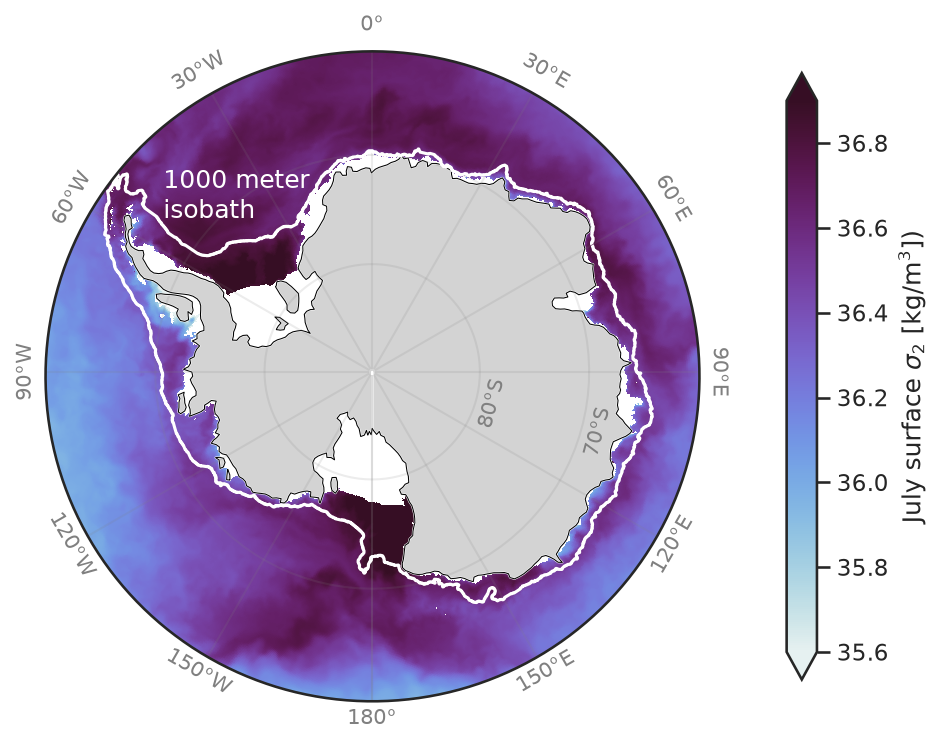

In [59]:
da = ds.sigma2.isel(zl=0)

fig = plt.figure(figsize=(7.5, 7.5))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
levels = np.arange(35.6, 37.0, 0.1)

plot_antarctic(
    da,
    ax,
    cmap=cmo.dense,
    mask_threshold=1e-8,
    draw_gridlines=True,
    gridline_lons=range(-180, 181, 30),
    gridline_lats=range(-90, 0, 10),
    draw_labels=True,
    plot_kwargs = {'vmin':float(levels.min()),
                   'vmax':float(levels.max())},
)

fig.colorbar(
    pc, ax=ax, shrink=0.7, pad=0.1, extend="both",
    label=r"July surface $\sigma_2$ [kg/m$^3$])", orientation="vertical"
)

ax.set_title("")

ax.contour(region.mask.geolon, region.mask.geolat, 
           region.mask, colors= "white", transform=ccrs.PlateCarree(),)
ax.text(
    -50, -65, "1000 meter\nisobath",
    transform=ccrs.PlateCarree(),
    color="w", fontsize=12,
    ha="left", va="center",
    zorder=7,
)